In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

zip_path = '/content/drive/MyDrive/Pneumonia Project/pneumonia_data.zip'

if os.path.exists(zip_path):
    print(f"[+] Đã tìm thấy file tại: {zip_path}")
    print("[*] Đang tiến hành copy và giải nén...")

    os.system(f'cp "{zip_path}" /content/')
    os.system('unzip -q /content/pneumonia_data.zip -d /content/pneumonia_data')

    print("\n🎉 GIẢI NÉN HOÀN TẤT! Dữ liệu đã sẵn sàng.")
else:
    print(f"\n[!] LỖI: Không tìm thấy file tại {zip_path}")
    print("Vui lòng kiểm tra lại đường dẫn trên Google Drive của bạn.")

[+] Đã tìm thấy file tại: /content/drive/MyDrive/Pneumonia Project/pneumonia_data.zip
[*] Đang tiến hành copy và giải nén...

🎉 GIẢI NÉN HOÀN TẤT! Dữ liệu đã sẵn sàng.


In [17]:
%%writefile dataset.py
"""
Dataset loader cho Pneumonia Classification.
- Tiền xử lý: CLAHE (cân bằng histogram thích ứng)
- Augmentation mạnh để chống overfitting và domain shift
- WeightedRandomSampler để cân bằng class trong batch
"""
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Su dung CLAHE
def apply_clahe(pil_img):
    img = np.array(pil_img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return Image.fromarray(img).convert('RGB')


class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.dataframe.iloc[idx]['Label']
        image = Image.open(img_path)
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


def prepare_dataloaders(data_dir, batch_size=32):
    """Chuẩn bị train/val DataLoaders với class balancing."""
    csv_path = os.path.join(data_dir, 'balanced_labels.csv')
    img_dir = os.path.join(data_dir, 'images')
    df = pd.read_csv(csv_path)

    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize(256),
            transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ColorJitter(brightness=0.2, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.1)),
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    }

    train_df, val_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df['Label']
    )
    train_dataset = PneumoniaDataset(train_df, img_dir, transform=data_transforms['train'])
    val_dataset = PneumoniaDataset(val_df, img_dir, transform=data_transforms['val'])

    # WeightedRandomSampler để cân bằng 1:1 trong mỗi batch
    labels = train_df['Label'].values
    class_count = np.array([len(np.where(labels == t)[0]) for t in np.unique(labels)])
    weight = 1. / class_count
    samples_weight = torch.from_numpy(np.array([weight[int(t)] for t in labels]))
    sampler = WeightedRandomSampler(samples_weight.double(), len(samples_weight))

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=sampler,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )
    return train_loader, val_loader


Writing dataset.py


In [18]:
%%writefile model.py
"""
Định nghĩa kiến trúc model.
- Backbone: ResNet18 pretrain ImageNet
- Selective fine-tuning: chỉ train Layer 3 + Layer 4
- Custom head: Dropout 0.3 + Linear → 1 logit (binary classification)
"""
import torch
import torch.nn as nn
from torchvision import models


def get_resnet18_model(device, freeze_mode='all'):
    """Khởi tạo model ResNet18 cho phân loại nhị phân.

    Args:
        device: torch.device (cuda hoặc cpu)
        freeze_mode: 'all' = đóng băng toàn bộ backbone (Stage 1)
                     'selective' = mở khóa layer3 + layer4 (Stage 2)
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_mode == 'all':
        for param in model.parameters():
            param.requires_grad = False
        print("[*] Freeze TOÀN BỘ backbone.")
    elif freeze_mode == 'selective':
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True
        print("[*] Fine-tune: Layer 3 + Layer 4.")

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 1)
    )
    return model.to(device)


Writing model.py


In [19]:
%%writefile train.py
"""
Training pipeline 3 giai đoạn:
- Stage 1: Freeze backbone, train classifier head (lr=1e-3)
- Stage 2: Fine-tune Layer 3+4 (lr=1e-5)
- Stage 3: Threshold tuning trên validation set
"""
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve
)
from dataset import prepare_dataloaders
from model import get_resnet18_model


class EarlyStopping:
    """Early stopping dựa trên validation loss."""
    def __init__(self, patience=5, path='best_model_v1.pth'):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)


def run_epoch(model, loader, criterion, optimizer, device, phase='train'):
    """Chạy 1 epoch (train hoặc validate) và trả về dict các metrics."""
    if phase == 'train':
        model.train()
        # Giữ BatchNorm ở eval khi backbone bị freeze
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                if not next(m.parameters()).requires_grad:
                    m.eval()
    else:
        model.eval()

    running_loss, total = 0.0, 0
    probs_list, labels_list = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        if phase == 'train':
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        total += labels.size(0)
        probs_list.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        labels_list.extend(labels.detach().cpu().numpy())

    probs_arr = np.array(probs_list)
    labels_arr = np.array(labels_list)
    preds_arr = (probs_arr >= 0.5).astype(int)

    return {
        'loss': running_loss / total,
        'acc': (preds_arr == labels_arr).mean(),
        'auc': roc_auc_score(labels_arr, probs_arr),
        'precision': precision_score(labels_arr, preds_arr, zero_division=0),
        'recall': recall_score(labels_arr, preds_arr, zero_division=0),
        'f1': f1_score(labels_arr, preds_arr, zero_division=0),
        'cm': confusion_matrix(labels_arr, preds_arr) if phase == 'val' else None,
    }


def get_val_predictions(model, val_loader, device):
    """Chạy inference trên val set, trả về (probs, labels) full set."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            p = torch.sigmoid(model(x)).cpu().numpy().flatten()
            all_probs.extend(p)
            all_labels.extend(y.numpy().flatten())
    return np.array(all_probs), np.array(all_labels)


def tune_threshold(all_probs, all_labels, target='f1'):
    """Tìm threshold tối ưu trên val set.

    Args:
        target: 'f1' (cân bằng) hoặc 'medical' (Recall >= 0.90)
    """
    precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

    if target == 'f1':
        f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
        best_idx = f1s[:-1].argmax()
        return (float(thresholds[best_idx]), float(f1s[best_idx]),
                float(precisions[best_idx]), float(recalls[best_idx]))

    elif target == 'medical':
        mask = recalls[:-1] >= 0.90
        if mask.any():
            valid_p = precisions[:-1][mask]
            valid_t = thresholds[mask]
            valid_r = recalls[:-1][mask]
            best_idx = valid_p.argmax()
            return (float(valid_t[best_idx]), None,
                    float(valid_p[best_idx]), float(valid_r[best_idx]))
        return None


def train_model():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, val_loader = prepare_dataloaders('/content/pneumonia_data', 32)

    criterion = nn.BCEWithLogitsLoss()

    history = {k: [] for k in ['t_loss', 'v_loss', 't_acc', 'v_acc',
                               't_auc', 'v_auc', 'v_recall', 'v_f1']}
    best_cm = None

    # ===== STAGE 1: FREEZE BACKBONE =====
    print("\n[STAGE 1] Freeze Backbone with Regularization")
    model = get_resnet18_model(DEVICE, freeze_mode='all')
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    early_stopper = EarlyStopping(patience=5, path='best_model_v1.pth')

    for epoch in range(8):
        t = run_epoch(model, train_loader, criterion, optimizer, DEVICE, 'train')
        v = run_epoch(model, val_loader, criterion, None, DEVICE, 'val')
        scheduler.step(v['loss'])
        for k, val in zip(history.keys(),
                          [t['loss'], v['loss'], t['acc'], v['acc'],
                           t['auc'], v['auc'], v['recall'], v['f1']]):
            history[k].append(val)
        print(f"E{epoch+1}/8 | Val Acc: {v['acc']:.4f} | Recall: {v['recall']:.4f} | "
              f"F1: {v['f1']:.4f} | AUC: {v['auc']:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        early_stopper(v['loss'], model)
        if early_stopper.early_stop:
            print("[!] Early stopping at Stage 1")
            break

    # ===== STAGE 2: FINE-TUNE =====
    print("\n[STAGE 2] Fine-tuning with Regularization")
    model.load_state_dict(torch.load('best_model_v1.pth'))
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    early_stopper = EarlyStopping(patience=5, path='best_model_v1.pth')

    for epoch in range(12):
        t = run_epoch(model, train_loader, criterion, optimizer, DEVICE, 'train')
        v = run_epoch(model, val_loader, criterion, None, DEVICE, 'val')
        scheduler.step(v['loss'])
        for k, val in zip(history.keys(),
                          [t['loss'], v['loss'], t['acc'], v['acc'],
                           t['auc'], v['auc'], v['recall'], v['f1']]):
            history[k].append(val)
        print(f"E{len(history['t_loss'])}/20 | Val Acc: {v['acc']:.4f} | "
              f"Recall: {v['recall']:.4f} | F1: {v['f1']:.4f} | AUC: {v['auc']:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        if v['loss'] <= min(history['v_loss']):
            best_cm = v['cm']
        early_stopper(v['loss'], model)
        if early_stopper.early_stop:
            print("[!] Early stopping at Stage 2")
            break

    # ===== STAGE 3: TUNE THRESHOLD =====
    print("\n[STAGE 3] Tuning decision threshold")
    model.load_state_dict(torch.load('best_model_v1.pth'))
    all_probs, all_labels = get_val_predictions(model, val_loader, DEVICE)

    thr_f1, f1_score_val, prec_f1, rec_f1 = tune_threshold(all_probs, all_labels, target='f1')
    print(f"[F1-Optimal] Threshold: {thr_f1:.4f} | F1: {f1_score_val:.4f} | "
          f"P: {prec_f1:.4f} | R: {rec_f1:.4f}")

    medical_result = tune_threshold(all_probs, all_labels, target='medical')
    if medical_result:
        thr_med, _, prec_med, rec_med = medical_result
        print(f"[Medical] Threshold: {thr_med:.4f} | P: {prec_med:.4f} | "
              f"R: {rec_med:.4f} (≥90%)")
    else:
        thr_med = None
        print("[Medical] Không tìm được threshold cho Recall ≥ 90%")

    # Lưu checkpoint với cả 2 threshold
    torch.save({
        'state_dict': model.state_dict(),
        'threshold_f1': thr_f1,
        'threshold_medical': thr_med,
        'val_f1': f1_score_val,
        'val_precision_f1': prec_f1,
        'val_recall_f1': rec_f1,
    }, 'best_model_final.pth')
    print(f"[*] Saved best_model_final.pth")

    # ===== VẼ LEARNING CURVES =====
    plt.figure(figsize=(18, 4))
    for i, (m, t_k, v_k) in enumerate([
        ('Loss', 't_loss', 'v_loss'),
        ('Recall & F1', 'v_recall', 'v_f1'),
        ('AUC', 't_auc', 'v_auc'),
    ]):
        plt.subplot(1, 3, i + 1)
        if t_k in history:
            plt.plot(history[t_k], label='Train')
        plt.plot(history[v_k], label='Val')
        plt.title(m); plt.legend()
    plt.tight_layout()
    plt.savefig('learning_curves_full.png')
    plt.show()

    # ===== CONFUSION MATRICES =====
    fig, axes = plt.subplots(1, 2 if not thr_med else 3, figsize=(6 * (3 if thr_med else 2), 5))
    if best_cm is not None:
        sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Threshold = 0.5')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    preds_f1 = (all_probs >= thr_f1).astype(int)
    cm_f1 = confusion_matrix(all_labels, preds_f1)
    sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title(f'F1-Optimal (Thr = {thr_f1:.3f})')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

    if thr_med:
        preds_med = (all_probs >= thr_med).astype(int)
        cm_med = confusion_matrix(all_labels, preds_med)
        sns.heatmap(cm_med, annot=True, fmt='d', cmap='Reds', ax=axes[2])
        axes[2].set_title(f'Medical (Thr = {thr_med:.3f})')
        axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig('confusion_matrices.png')
    plt.show()


if __name__ == '__main__':
    train_model()


Writing train.py


In [20]:
%%writefile evaluate.py
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# 1. Định nghĩa bộ đọc dữ liệu và tiền xử lý CLAHE giống lúc huấn luyện
def apply_clahe(pil_img):
    img = np.array(pil_img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return Image.fromarray(img).convert('RGB')

class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.dataframe.iloc[idx]['Label']
        image = Image.open(img_path)
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

def evaluate():
    device = torch.device("cpu")
    model_path = '/content/best_model_final.pth'
    data_dir = '/content/pneumonia_data'

    csv_path = os.path.join(data_dir, 'balanced_labels.csv')
    img_dir = os.path.join(data_dir, 'images')

    # Chia dữ liệu đúng tỷ lệ Validation lúc huấn luyện
    df = pd.read_csv(csv_path)
    _, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    val_dataset = PneumoniaDataset(val_df, img_dir, transform=val_transforms)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    # Khởi tạo mô hình ResNet18
    model = models.resnet18(weights=None)

    # SỬA LỖI TẠI ĐÂY: Khai báo lớp FC khớp hoàn toàn với file .pth của bạn
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )

    # Nạp trọng số mô hình
    print("⏳ Đang nạp trọng số mô hình...")
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    threshold = checkpoint.get('threshold_f1', 0.455)

    all_probs = []
    all_labels = []

    print("⏳ AI đang quét tập dữ liệu đánh giá...")
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(-1).cpu().numpy()

            if probs.ndim == 0:
                probs = np.expand_dims(probs, axis=0)

            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = (all_probs >= threshold).astype(int)

    # Tính toán các chỉ số
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # In kết quả báo cáo
    print("\n" + "="*50)
    print(f"📊 KẾT QUẢ ĐÁNH GIÁ TỪ FILE EVALUATE.PY (Threshold: {threshold:.3f})")
    print("="*50)
    print(f"  - Accuracy:    {acc*100:.2f}%")
    print(f"  - Precision:   {precision*100:.2f}%")
    print(f"  - Recall:      {recall*100:.2f}%")
    print(f"  - Specificity: {specificity*100:.2f}%")
    print(f"  - F1-Score:    {f1*100:.2f}%")
    print("-"*50)
    print("\n📝 CHI TIẾT CLASSIFICATION REPORT:")
    print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

if __name__ == '__main__':
    evaluate()

Writing evaluate.py


In [13]:
!python evaluate.py

⏳ Đang nạp trọng số mô hình...
⏳ AI đang quét tập dữ liệu đánh giá...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

📊 KẾT QUẢ ĐÁNH GIÁ TỪ FILE EVALUATE.PY (Threshold: 0.605)
  - Accuracy:    79.48%
  - Precision:   59.48%
  - Recall:      55.94%
  - Specificity: 87.31%
  - F1-Score:    57.66%
--------------------------------------------------

📝 CHI TIẾT CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.86      0.87      0.86       859
   Pneumonia       0.59      0.56      0.58       286

    accuracy                           0.79      1145
   macro avg       0.73      0.72      0.72      1145
weighted avg       0.79      0.79      0.79      1145



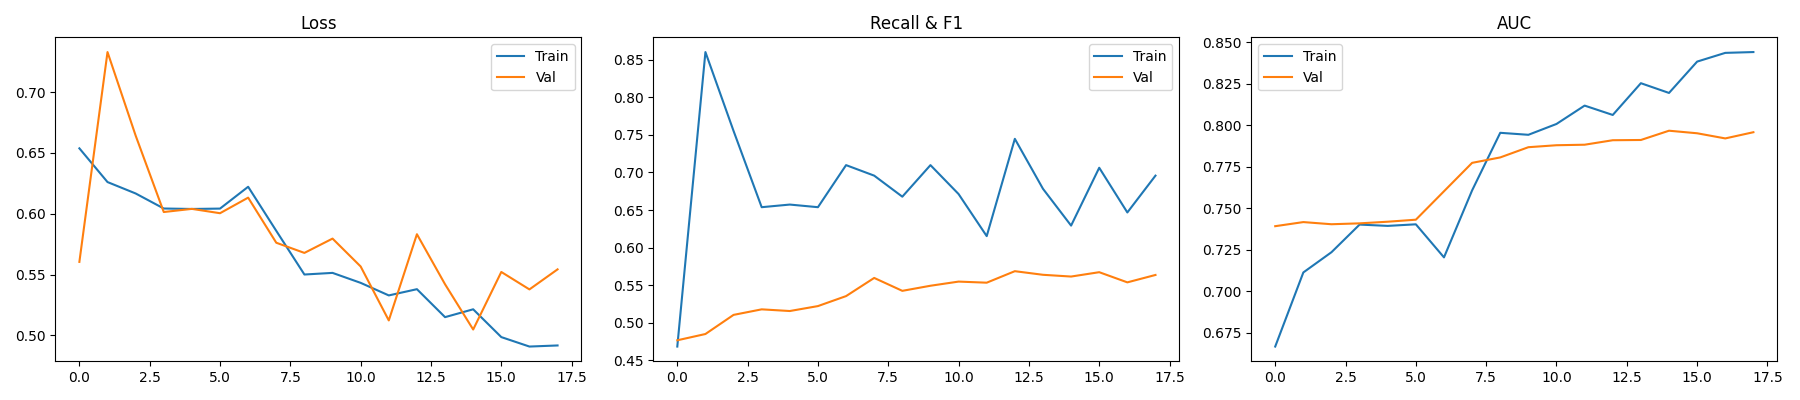

In [ ]:
from IPython.display import Image, display
import os

# Hiển thị biểu đồ đã được lưu từ script train.py
if os.path.exists('learning_curves_full.png'):
    display(Image('learning_curves_full.png'))
else:
    print("Chưa tìm thấy file biểu đồ. Vui lòng đảm bảo cell huấn luyện đã chạy xong.")

In [21]:
%%writefile predict.py
"""
Dự đoán ảnh X-quang đơn lẻ (dùng cho demo).
- Tiền xử lý CLAHE
- Test-Time Augmentation (TTA): trung bình prediction của ảnh gốc + ảnh lật ngang
- Sử dụng threshold tối ưu đã lưu trong checkpoint
"""
import sys
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from model import get_resnet18_model
from dataset import apply_clahe

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def predict(image_path, ckpt_path='best_model_final.pth', mode='f1'):
    """Dự đoán 1 ảnh.

    Args:
        image_path: đường dẫn ảnh X-quang
        ckpt_path: checkpoint đã train
        mode: 'f1' (cân bằng) hoặc 'medical' (Recall cao)
    """
    # Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    if mode == 'medical' and ckpt.get('threshold_medical'):
        threshold = ckpt['threshold_medical']
    else:
        threshold = ckpt.get('threshold_f1', 0.455)

    # Load model
    model = get_resnet18_model(DEVICE, freeze_mode='selective')
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    # Tiền xử lý
    img = Image.open(image_path).convert('RGB')
    img_clahe = apply_clahe(img)

    # Test-Time Augmentation
    probs = []
    with torch.no_grad():
        for im in [img_clahe, img_clahe.transpose(Image.FLIP_LEFT_RIGHT)]:
            x = transform(im).unsqueeze(0).to(DEVICE)
            probs.append(torch.sigmoid(model(x)).item())

    prob = float(np.mean(probs))
    label = "PNEUMONIA" if prob >= threshold else "NORMAL"
    confidence = prob if prob >= threshold else (1 - prob)

    print(f"\n{'='*50}")
    print(f"📷 File: {image_path}")
    print(f"{'='*50}")
    print(f"  Probability (Pneumonia): {prob:.4f} ({prob*100:.2f}%)")
    print(f"  Threshold ({mode}):      {threshold}")
    print(f"  Confidence:              {confidence*100:.2f}%")
    print(f"  → PREDICTION: {label}")
    print(f"{'='*50}\n")

    return {'probability': prob, 'label': label,
            'confidence': confidence, 'threshold': threshold}


if __name__ == '__main__':
    if len(sys.argv) < 2:
        print("Usage: python predict.py <image_path> [mode]")
        print("  mode: 'f1' (default) or 'medical'")
        sys.exit(1)
    image_path = sys.argv[1]
    mode = sys.argv[2] if len(sys.argv) > 2 else 'f1'
    predict(image_path, mode=mode)


Writing predict.py


In [ ]:
!cp /content/best_model_v1.pth /content/drive/MyDrive/Pneumonia\ Project/best_model_BACKUP_resnet18.pth
!cp /content/best_model_final.pth /content/drive/MyDrive/Pneumonia\ Project/best_model_final_BACKUP.pth

⏳ AI đang quét và tính toán đồ thị trên tập Validation (khoảng vài giây)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


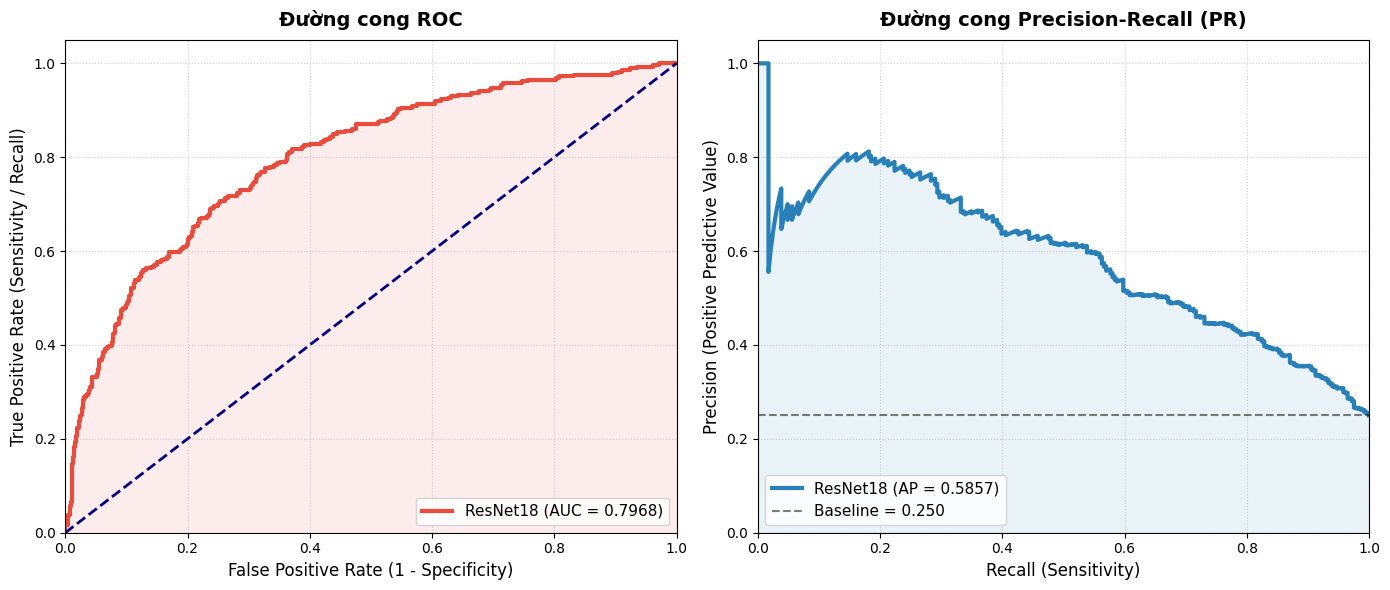

🎉 THÀNH CÔNG! Đã xuất đồ thị chất lượng cao tại file: auc_roc_pr_curves.png


In [4]:
# Biểu đồ AUC-ROC, AUC
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# =====================================================================
# 1. ĐỊNH NGHĨA BỘ ĐỌC DỮ LIỆU & TIỀN XỬ LÝ
# =====================================================================
def apply_clahe(pil_img):
    img = np.array(pil_img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return Image.fromarray(img).convert('RGB')

class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.dataframe.iloc[idx]['Label']
        image = Image.open(img_path)
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# =====================================================================
# 2. THIẾT LẬP ĐƯỜNG DẪN & TẢI TẬP VALIDATION
# =====================================================================
data_dir = '/content/pneumonia_data'  # Thư mục chứa dữ liệu đã giải nén
model_path = '/content/best_model_final_BACKUP.pth'  # Thư mục chứa file model pth

csv_path = os.path.join(data_dir, 'balanced_labels.csv')
img_dir = os.path.join(data_dir, 'images')

if not os.path.exists(csv_path) or not os.path.exists(model_path):
    print("❌ LỖI: Vui lòng kiểm tra lại xem dữ liệu đã được giải nén vào `/content/pneumonia_data` "
          "và file `best_model_final.pth` đã được kéo thả hoàn tất vào `/content/` chưa!")
else:
    df = pd.read_csv(csv_path)
    _, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    val_dataset = PneumoniaDataset(val_df, img_dir, transform=val_transforms)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    # =====================================================================
    # 3. KHỞI TẠO MÔ HÌNH VÀ SỬA LẠI LỚP FC KHỚP 100% VỚI WEIGHTS (ĐÃ KHẮC PHỤC LỖI)
    # =====================================================================
    device = torch.device("cpu")
    model = models.resnet18(weights=None)

    # Cấu hình chuỗi lớp phân loại 2 tầng tương thích hoàn toàn với file .pth của bạn
    model.fc = nn.Sequential(
        nn.Dropout(0.3),           # fc.0
        nn.Linear(512, 256),       # fc.1 -> Kích thước [256, 512]
        nn.ReLU(),                 # fc.2
        nn.Dropout(0.3),           # fc.3
        nn.Linear(256, 1)          # fc.4 -> Kích thước [1, 256]
    )

    # Nạp trọng số mô hình đảm bảo không lỗi strict
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    # =====================================================================
    # 4. TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP VALIDATION
    # =====================================================================
    all_probs = []
    all_labels = []

    print("⏳ AI đang quét và tính toán đồ thị trên tập Validation (khoảng vài giây)...")
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(-1).cpu().numpy()

            if probs.ndim == 0:
                probs = np.expand_dims(probs, axis=0)

            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # =====================================================================
    # 5. TÍNH TOÁN CÁC CHỈ SỐ VÀ VẼ ĐỒ THỊ
    # =====================================================================
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Đồ thị AUC-ROC
    axes[0].plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ResNet18 (AUC = {roc_auc:.4f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
    axes[0].set_title('Đường cong ROC', fontsize=14, fontweight='bold', pad=10)
    axes[0].legend(loc="lower right", fontsize=11)
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # Đồ thị AUC-PR
    baseline_pr = all_labels.sum() / len(all_labels)
    axes[1].plot(recall, precision, color='#2980b9', lw=3, label=f'ResNet18 (AP = {pr_auc:.4f})')
    axes[1].axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline = {baseline_pr:.3f}')
    axes[1].fill_between(recall, precision, alpha=0.1, color='#2980b9')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
    axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
    axes[1].set_title('Đường cong Precision-Recall (PR)', fontsize=14, fontweight='bold', pad=10)
    axes[1].legend(loc="lower left", fontsize=11)
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    output_image_path = 'auc_roc_pr_curves.png'
    plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"🎉 THÀNH CÔNG! Đã xuất đồ thị chất lượng cao tại file: {output_image_path}")

⏳ AI đang quét dữ liệu và khởi tạo Ma trận nhầm lẫn...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


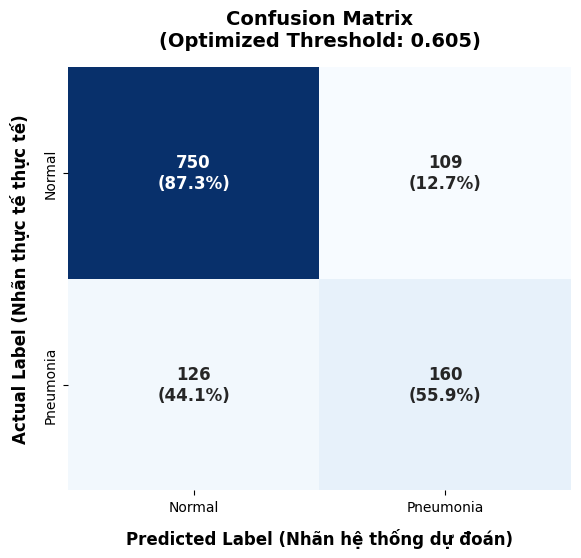

🎉 THÀNH CÔNG! Đã vẽ đồ thị ma trận nhầm lẫn và lưu tại file: confusion_matrix.png


In [14]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# =====================================================================
# 1. ĐỊNH NGHĨA BỘ ĐỌC DỮ LIỆU & TIỀN XỬ LÝ (TỰ CHẠY ĐỘC LẬP)
# =====================================================================
def apply_clahe(pil_img):
    img = np.array(pil_img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return Image.fromarray(img).convert('RGB')

class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.dataframe.iloc[idx]['Label']
        image = Image.open(img_path)
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# =====================================================================
# 2. THIẾT LẬP ĐƯỜNG DẪN DỮ LIỆU & FILE TRỌNG SỐ
# =====================================================================
data_dir = '/content/pneumonia_data'
model_path = '/content/best_model_final.pth'

csv_path = os.path.join(data_dir, 'balanced_labels.csv')
img_dir = os.path.join(data_dir, 'images')

if not os.path.exists(csv_path) or not os.path.exists(model_path):
    print("❌ LỖI: Vui lòng kiểm tra lại xem dữ liệu đã được giải nén vào `/content/pneumonia_data` "
          "và file `best_model_final.pth` đã được kéo thả hoàn tất vào `/content/` chưa!")
else:
    df = pd.read_csv(csv_path)
    _, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    val_dataset = PneumoniaDataset(val_df, img_dir, transform=val_transforms)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    # =====================================================================
    # 3. KHỔI TẠO MÔ HÌNH VÀ NẠP TRỌNG SỐ (CHẠY CPU)
    # =====================================================================
    device = torch.device("cpu")
    model = models.resnet18(weights=None)

    # Chuỗi lớp phân loại 2 tầng tương thích hoàn toàn với file .pth của bạn
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )

    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    threshold = checkpoint.get('threshold_f1', 0.455)

    # =====================================================================
    # 4. TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP VALIDATION
    # =====================================================================
    all_preds = []
    all_labels = []

    print("⏳ AI đang quét dữ liệu và khởi tạo Ma trận nhầm lẫn...")
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(-1).cpu().numpy() # Sửa lỗi định dạng chiều mảng cụ thể (-1)

            if probs.ndim == 0:
                probs = np.expand_dims(probs, axis=0)

            preds = (probs >= threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # =====================================================================
    # 5. TÍNH TOÁN VÀ TRỰC QUAN HÓA MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
    # =====================================================================
    cm = confusion_matrix(all_labels, all_preds)

    # Tạo nhãn text tùy chỉnh kết hợp [Số ca thực tế + Tỉ lệ % tương ứng] cho mỗi ô
    annot_labels = np.empty_like(cm, dtype=object)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            count = cm[i, j]
            percentage = count / cm[i].sum() * 100
            annot_labels[i, j] = f"{count}\n({percentage:.1f}%)"

    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'],
                cbar=False, annot_kws={"size": 12, "weight": "bold"})

    plt.ylabel('Actual Label (Nhãn thực tế thực tế)', fontsize=12, fontweight='bold', labelpad=10)
    plt.xlabel('Predicted Label (Nhãn hệ thống dự đoán)', fontsize=12, fontweight='bold', labelpad=10)
    plt.title(f'Confusion Matrix\n(Optimized Threshold: {threshold:.3f})', fontsize=14, fontweight='bold', pad=15)

    output_image_path = 'confusion_matrix.png'
    plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"🎉 THÀNH CÔNG! Đã vẽ đồ thị ma trận nhầm lẫn và lưu tại file: {output_image_path}")

In [16]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =====================================================================
# 1. ĐỊNH NGHĨA BỘ ĐỌC DỮ LIỆU & TIỀN XỬ LÝ (TỰ CHẠY ĐỘC LẬP)
# =====================================================================
def apply_clahe(pil_img):
    img = np.array(pil_img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return Image.fromarray(img).convert('RGB')

class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.dataframe.iloc[idx]['Label']
        image = Image.open(img_path)
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# =====================================================================
# 2. THIẾT LẬP ĐƯỜNG DẪN DỮ LIỆU & FILE TRỌNG SỐ
# =====================================================================
data_dir = '/content/pneumonia_data'
model_path = '/content/best_model_final.pth'

csv_path = os.path.join(data_dir, 'balanced_labels.csv')
img_dir = os.path.join(data_dir, 'images')

if not os.path.exists(csv_path) or not os.path.exists(model_path):
    print("❌ LỖI: Vui lòng kiểm tra lại xem dữ liệu đã được giải nén vào `/content/pneumonia_data` và file `best_model_final.pth` chưa!")
else:
    # Chia tập dữ liệu chuẩn xác theo tỷ lệ lúc train
    df = pd.read_csv(csv_path)
    _, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    val_dataset = PneumoniaDataset(val_df, img_dir, transform=val_transforms)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    # =====================================================================
    # 3. KHỔI TẠO MÔ HÌNH VÀ NẠP TRỌNG SỐ
    # =====================================================================
    device = torch.device("cpu")
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )

    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    # =====================================================================
    # 4. THU THẬP XÁC SUẤT (CHỈ QUÉT 1 LẦN DUY NHẤT)
    # =====================================================================
    all_probs = []
    all_labels = []

    print("⏳ AI đang quét tập Validation để thu thập xác suất dự đoán...")
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(-1).cpu().numpy()
            if probs.ndim == 0:
                probs = np.expand_dims(probs, axis=0)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # =====================================================================
    # 5. TÍNH TOÁN VÀ SO SÁNH CÁC NGƯỠNG (THRESHOLDS)
    # =====================================================================
    thresholds_to_test = [0.4, 0.455, 0.5]
    results_list = []

    for t in thresholds_to_test:
        preds = (all_probs >= t).astype(int)

        acc = accuracy_score(all_labels, preds) * 100
        prec = precision_score(all_labels, preds) * 100
        rec = recall_score(all_labels, preds) * 100
        f1 = f1_score(all_labels, preds) * 100

        tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()
        spec = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0

        results_list.append({
            'Threshold': t,
            'Accuracy (%)': f"{acc:.2f}%",
            'Precision (%)': f"{prec:.2f}%",
            'Recall (%)': f"{rec:.2f}%",
            'Specificity (%)': f"{spec:.2f}%",
            'F1-Score (%)': f"{f1:.2f}%"
        })

    # In bảng so sánh đẹp mắt dạng bảng dữ liệu
    df_compare = pd.DataFrame(results_list)
    print("\n" + "="*70)
    print("📊 BẢNG SO SÁNH CHỈ SỐ MÔ HÌNH THEO CÁC NGƯỠNG THRESHOLD KHÁC NHAU")
    print("="*70)
    print(df_compare.to_string(index=False))
    print("-"*70)

⏳ AI đang quét tập Validation để thu thập xác suất dự đoán...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



📊 BẢNG SO SÁNH CHỈ SỐ MÔ HÌNH THEO CÁC NGƯỠNG THRESHOLD KHÁC NHAU
 Threshold Accuracy (%) Precision (%) Recall (%) Specificity (%) F1-Score (%)
     0.400       72.23%        46.38%     71.68%          72.41%       56.32%
     0.455       74.93%        49.87%     67.13%          77.53%       57.23%
     0.500       75.46%        50.70%     62.94%          79.63%       56.16%
----------------------------------------------------------------------
